# 1. Importation des Bibliothèques et chargement des données

In [18]:
# IMPORTATION DES BIBLIOTHÈQUES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk 
import re 
from nltk.corpus import stopwords   
from nltk.stem import WordNetLemmatizer 
# Téléchargement des ressources NLP (Natural Language Processing)
nltk.download('stopwords') 
nltk.download('wordnet')   
nltk.download('omw-1.4') 
nltk.download('punkt') 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Chargement et nettoyage des Données

In [19]:
# CHARGEMENT DES DONNÉES
df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv', index_col=0)
# Suppression des valeurs manquantes dans la colonne 'Review Text'
df = df.dropna(subset=['Review Text'])
# Aperçu rapide des 5 premières lignes
print("Taille du dataset après nettoyage des NaN :", df.shape)
df.head() 

Taille du dataset après nettoyage des NaN : (22641, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [20]:
# PRÉTRAITEMENT DU TEXTE (PREPROCESSING)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Passage en minuscules et retrait des caractères spéciaux
    text = re.sub(r'[^a-zA-Z]', ' ', str(text).lower())
    
    # 2. Tokenization (découpage de phrases en mots)
    words = text.split()
    
    # 3. Retrait des stopwords et Lemmatisation 
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return ' '.join(words) 

# Application de la fonction sur tout le dataset
print("⏳ Nettoyage en cours... Veuillez patienter.")
df['Cleaned_Review'] = df['Review Text'].apply(clean_text)
print("✅ Nettoyage terminé !")

⏳ Nettoyage en cours... Veuillez patienter.
✅ Nettoyage terminé !


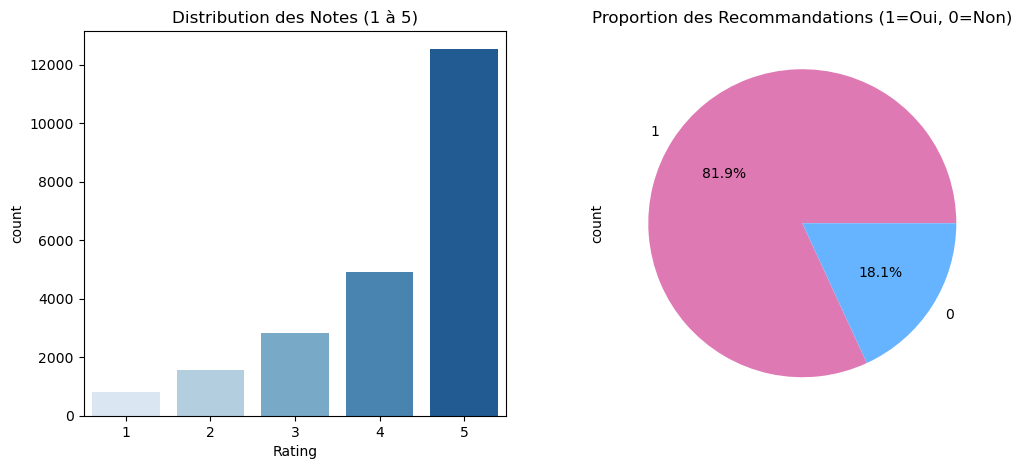

In [21]:
# ANALYSE VISUELLE 
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1)
sns.countplot(x='Rating', data=df, palette='Blues')
plt.title('Distribution des Notes (1 à 5)')

# Répartition des Recommandations
plt.subplot(1, 2, 2)
df['Recommended IND'].value_counts().plot.pie(autopct='%1.1f%%', colors=["#df79b4",'#66b3ff'])
plt.title('Proportion des Recommandations (1=Oui, 0=Non)')

plt.show()

# 2. Prétraitement du Texte (NLP Preprocessing)

In [22]:
#Data Splitting
from sklearn.model_selection import train_test_split 
# 1. Définition des variables X (Entrée) et y (Cible)
X = df['Cleaned_Review']
y = df['Recommended IND']

# 2. Division des données (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de X_train : {X_train.shape}") 
print(f"Taille de X_test : {X_test.shape}")

Taille de X_train : (18112,)
Taille de X_test : (4529,)


# 3. Vectorisation des données avec TF-IDF

In [23]:
#La Vectorisation (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialisation dyal l-Vectoriseur
tfidf = TfidfVectorizer(max_features=2000)

# 2. Transformation des données
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Nombre de mots (Vocabulaire) : {len(tfidf.get_feature_names_out())}")

Nombre de mots (Vocabulaire) : 2000


# 4. Modélisation Supervisée : Analyse de Sentiment (Naive Bayes)

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Création dyal l-Modèle
model = MultinomialNB()

# 2. L'entraînement (Fit)
model.fit(X_train_tfidf, y_train)

# 3. La prédiction 
y_pred = model.predict(X_test_tfidf)

# 4. Évaluation de la performance globale (Accuracy) et détaillée (Precision, Recall, F1-score)
print(f"Accuracy Score : {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred))

Accuracy Score : 0.86

Classification Report :
              precision    recall  f1-score   support

           0       0.89      0.27      0.42       812
           1       0.86      0.99      0.92      3717

    accuracy                           0.86      4529
   macro avg       0.88      0.63      0.67      4529
weighted avg       0.87      0.86      0.83      4529



 Test du modèle sur de nouvelles données

In [25]:
# 1. Définition de nouveaux exemples d'avis pour le test
new_reviews = [
    "I absolutely love this dress, the fabric is amazing!", # Positive
    "The size was too small and the material is very cheap.", # Negative
    "It's okay, but not what I expected for the price." # Neutral/Negative
]

# 2. Transformation du texte en vecteurs numériques (Vectorization)
new_reviews_transformed = tfidf.transform(new_reviews)

# 3. Prédiction du sentiment à l'aide du modèle entraîné (Naive Bayes)
predictions = model.predict(new_reviews_transformed)

# 4. Affichage des résultats de la prédiction
for review, pred in zip(new_reviews, predictions):
    sentiment = "Recommended (1)" if pred == 1 else "Not Recommended (0)"
    print(f"Review: {review}\nSentiment prédit: {sentiment}\n" + "-"*30)

Review: I absolutely love this dress, the fabric is amazing!
Sentiment prédit: Recommended (1)
------------------------------
Review: The size was too small and the material is very cheap.
Sentiment prédit: Not Recommended (0)
------------------------------
Review: It's okay, but not what I expected for the price.
Sentiment prédit: Recommended (1)
------------------------------


Matrice de confusion


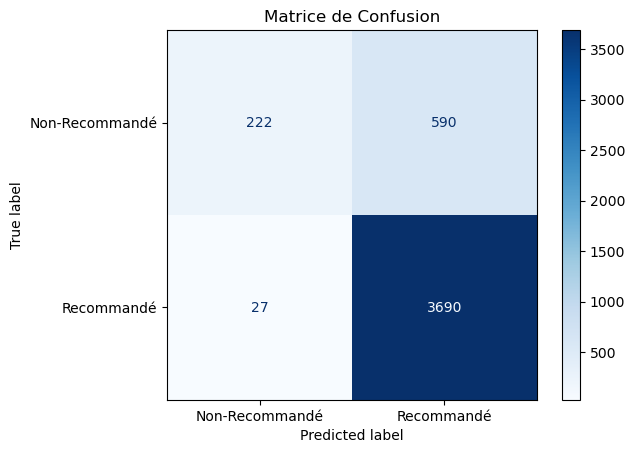

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Générer la matrice
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Recommandé', 'Recommandé'])

# Affichage
disp.plot(cmap='Blues')
plt.title('Matrice de Confusion')
plt.show()

Analyse des erreurs (Faux Positifs)

In [11]:
import pandas as pd

# 1. Création d'un DataFrame pour comparer les valeurs réelles et les prédictions
results = pd.DataFrame({'Review': X_test, 'Réel': y_test, 'Prédit': y_pred})

# 2. Extraction des erreurs de type 'Faux Positifs'
errors = results[(results['Réel'] == 0) & (results['Prédit'] == 1)]

print(f"Nombre d'erreurs de type 'Faux Positifs' : {len(errors)}")
print("\nExemples de reviews mal classées :")
print(errors['Review'].head(5))

Nombre d'erreurs de type 'Faux Positifs' : 590

Exemples de reviews mal classées :
2494     hanger look like great lbd quite bell shape dr...
12110    returned dress color pictured online photo lik...
14774    run small normally wear ag stevie paige jean o...
670      really wanted skirt work look flattering great...
20001    wondering whether purchase top decided last we...
Name: Review, dtype: object


 Sauvegarde des modèles (Partie Supervisée)

In [12]:
import joblib
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Modèle enregistré avec succès ! ✅")

Modèle enregistré avec succès ! ✅


# 5. Apprentissage Non Supervisé : Clustering avec K-Means et PCA

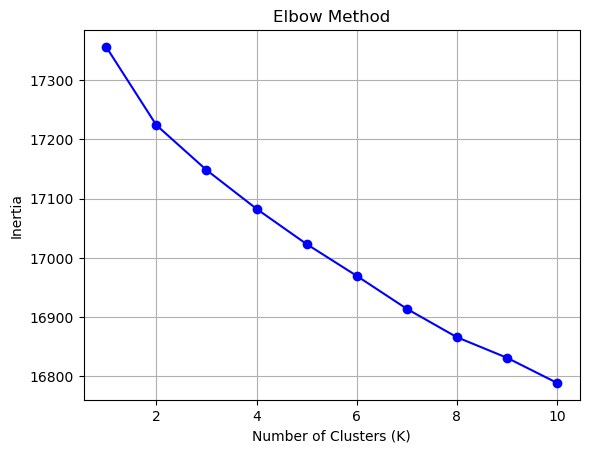

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# 1. Initialisation d'une liste pour stocker les valeurs de l'inertie
inertia = []
K_range = range(1, 11) # Test du modèle pour K allant de 1 à 10
# 2. Boucle d'entraînement pour chaque valeur de K
for k in K_range:
    # Initialisation de K-Means avec n_init=10 pour garantir la stabilité des résultats
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Entraînement sur la matrice TF-IDF
    km.fit(X_train_tfidf)
    # Récupération de l'inertie (Somme des carrés des distances intra-classe)
    inertia.append(km.inertia_)
# 3. Visualisation du graphique de l'Elbow Method
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

Segmentation des avis clients avec K-Means

In [26]:
# 1. Initialisation du modèle K-Means avec K=3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Entraînement et prédiction (Clustering) sur les données TF-IDF
clusters = kmeans.fit_predict(X_train_tfidf)

# 3. Ajout des résultats au DataFrame original (sous-ensemble Train)
df_train = df.loc[X_train.index].copy() # L'utilisation de .loc permet de garantir la correspondance des index après le nettoyage
df_train['cluster'] = clusters

# 4. Vérification de la répartition des avis par cluster
print(df_train['cluster'].value_counts())
print("\nLe volume de df_train est:", df_train.shape)

cluster
0    9947
1    4594
2    3571
Name: count, dtype: int64

Le volume de df_train est: (18112, 12)


Interprétation des Clusters (Analyse des mots-clés)

In [15]:
import numpy as np

# 1. Extraction des index des mots les plus représentatifs par cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1] #On trie les poids des centroïdes par ordre décroissant pour chaque cluster

# 2. Récupération du vocabulaire à partir du vectoriseur TF-IDF
terms = tfidf.get_feature_names_out()

# 3. Affichage des 10 mots les plus fréquents pour chaque cluster
print("🌟 Top 10 words per cluster 🌟")
for i in range(3):
    print(f"\n--- Cluster {i} ---")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(top_words)

🌟 Top 10 words per cluster 🌟

--- Cluster 0 ---
['love', 'top', 'great', 'color', 'look', 'fit', 'like', 'shirt', 'wear', 'sweater']

--- Cluster 1 ---
['size', 'small', 'fit', 'top', 'run', 'ordered', 'large', 'medium', 'wear', 'would']

--- Cluster 2 ---
['dress', 'fit', 'love', 'size', 'wear', 'like', 'look', 'beautiful', 'great', 'flattering']


Visualisation des Clusters avec PCA (Principal Component Analysis)

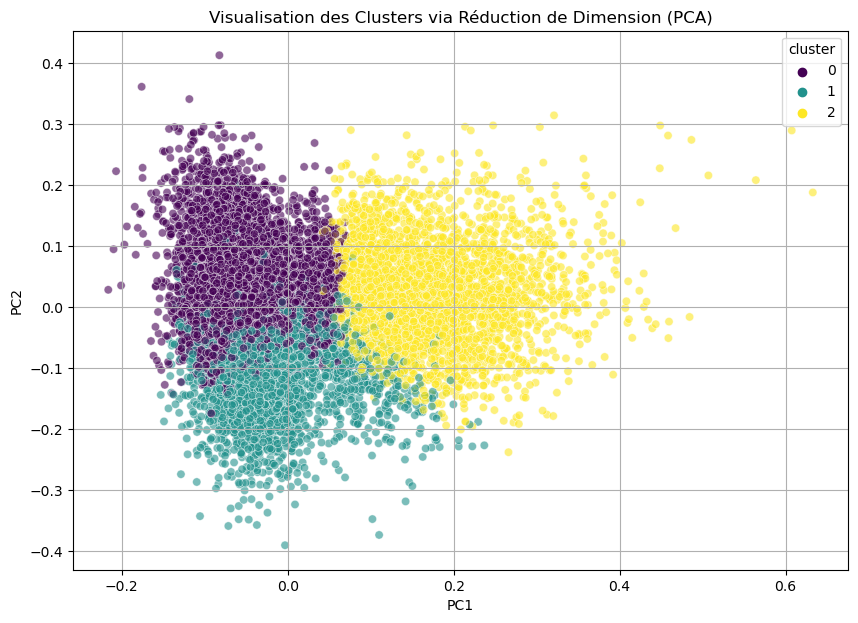

In [16]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Initialisation de la PCA pour réduire les données à 2 dimensions
pca = PCA(n_components=2, random_state=42)

# 2. Transformation de la matrice TF-IDF (Sparse Matrix) en coordonnées 2D (Dense Matrix)
X_pca = pca.fit_transform(X_train_tfidf.toarray())

# 3. Création d'un DataFrame dédié à la visualisation
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters  

# 4. Génération du graphique de dispersion (Scatter Plot)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='viridis', alpha=0.6)
# Configuration de l'affichage
plt.title('Visualisation des Clusters via Réduction de Dimension (PCA)')
plt.grid(True)
plt.show()

In [17]:
# Sauvegarde du modèle de Clustering (K-Means)
joblib.dump(kmeans, 'kmeans_clustering_model.pkl')
print("✅ Modèle de clustering enregistré avec succès !")

✅ Modèle de clustering enregistré avec succès !
